In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [29]:
file_path = "../data/diabetes_cleaned.csv"
df = pd.read_csv(file_path)
df1 = pd.read_csv('../data/diabetes_dataset.csv')
print("✅ Loaded cleaned dataset:", df.shape)
df.head()


✅ Loaded cleaned dataset: (10000, 21)


,Age,Sex,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Dietary_Intake_Calories,Family_History_of_Diabetes,Ethnicity_Asian,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_High,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Heavy,Alcohol_Consumption_Moderate,Alcohol_Consumption_None,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never
0,0.932846,0,1.034242,-0.792422,-0.289018,0.438405,-1.680810,0,0,0,0,1,0,0,1,0,1,0,0,0,1
1,0.235631,1,-0.861859,-1.626765,1.300070,1.036593,-0.124869,0,1,0,0,0,0,0,1,0,1,0,1,0,0
2,-0.740471,0,-0.716005,1.321247,0.191960,1.571813,-1.477072,1,0,1,0,0,0,1,0,1,0,0,0,1,0
3,1.211732,1,0.531856,0.389564,0.866924,-0.222749,1.470146,1,1,0,0,0,0,1,0,0,1,0,0,0,1
4,-1.228521,0,0.661504,1.112661,0.308883,-0.757970,0.584027,0,1,0,0,0,0,0,1,1,0,0,1,0,0


In [30]:
# Create a new binary target column 'Diabetes'
# Using a threshold of 125 mg/dL (commonly used diagnostic threshold)
if 'Fasting_Blood_Glucose' in df1.columns:
    
    df["Diabetes"] = np.where(
        (df1["Fasting_Blood_Glucose"] >= 126)| (df1["HbA1c"] >= 6.5),
        1,
        0
    )

    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

else:
    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

df["Diabetes"].value_counts()


✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5


Diabetes
1    9047
0     953
Name: count, dtype: int64

In [31]:
print("Shape:", df1.shape)
df1.info()

# Summary (numeric only)
df1.describe()


Shape: (10000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     10000 non-null  int64  
 1   Age                            10000 non-null  int64  
 2   Sex                            10000 non-null  object 
 3   Ethnicity                      10000 non-null  object 
 4   BMI                            10000 non-null  float64
 5   Waist_Circumference            10000 non-null  float64
 6   Fasting_Blood_Glucose          10000 non-null  float64
 7   HbA1c                          10000 non-null  float64
 8   Blood_Pressure_Systolic        10000 non-null  int64  
 9   Blood_Pressure_Diastolic       10000 non-null  int64  
 10  Cholesterol_Total              10000 non-null  float64
 11  Cholesterol_HDL                10000 non-null  float64
 12  Cholesterol_LDL             

,Unnamed: 0,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Dietary_Intake_Calories,Family_History_of_Diabetes,Previous_Gestational_Diabetes
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,44.620400,29.418150,94.79707,134.776210,9.507510,134.163700,89.558700,225.165540,55.019340,134.35377,55.16822,5.503430,2742.481900,0.507000,0.516500
std,2886.89568,14.343489,6.170866,14.38329,37.633544,3.176421,26.110317,17.237792,42.963744,14.537371,37.50238,25.88180,1.455091,716.643803,0.499976,0.499753
min,0.00000,20.000000,18.500000,70.00000,70.000000,4.000000,90.000000,60.000000,150.000000,30.000000,70.00000,10.00000,3.000000,1500.000000,0.000000,0.000000
25%,2499.75000,32.000000,24.100000,82.20000,102.175000,6.800000,112.000000,75.000000,187.875000,42.300000,101.67500,32.60000,4.200000,2129.000000,0.000000,0.000000
50%,4999.50000,45.000000,29.500000,94.90000,134.500000,9.500000,134.000000,89.000000,225.500000,55.200000,134.40000,55.45000,5.500000,2727.000000,1.000000,1.000000
75%,7499.25000,57.000000,34.700000,107.00000,167.800000,12.300000,157.000000,105.000000,262.400000,67.900000,166.40000,77.50000,6.800000,3368.000000,1.000000,1.000000
max,9999.00000,69.000000,40.000000,120.00000,200.000000,15.000000,179.000000,119.000000,300.000000,80.000000,200.00000,100.00000,8.000000,3999.000000,1.000000,1.000000


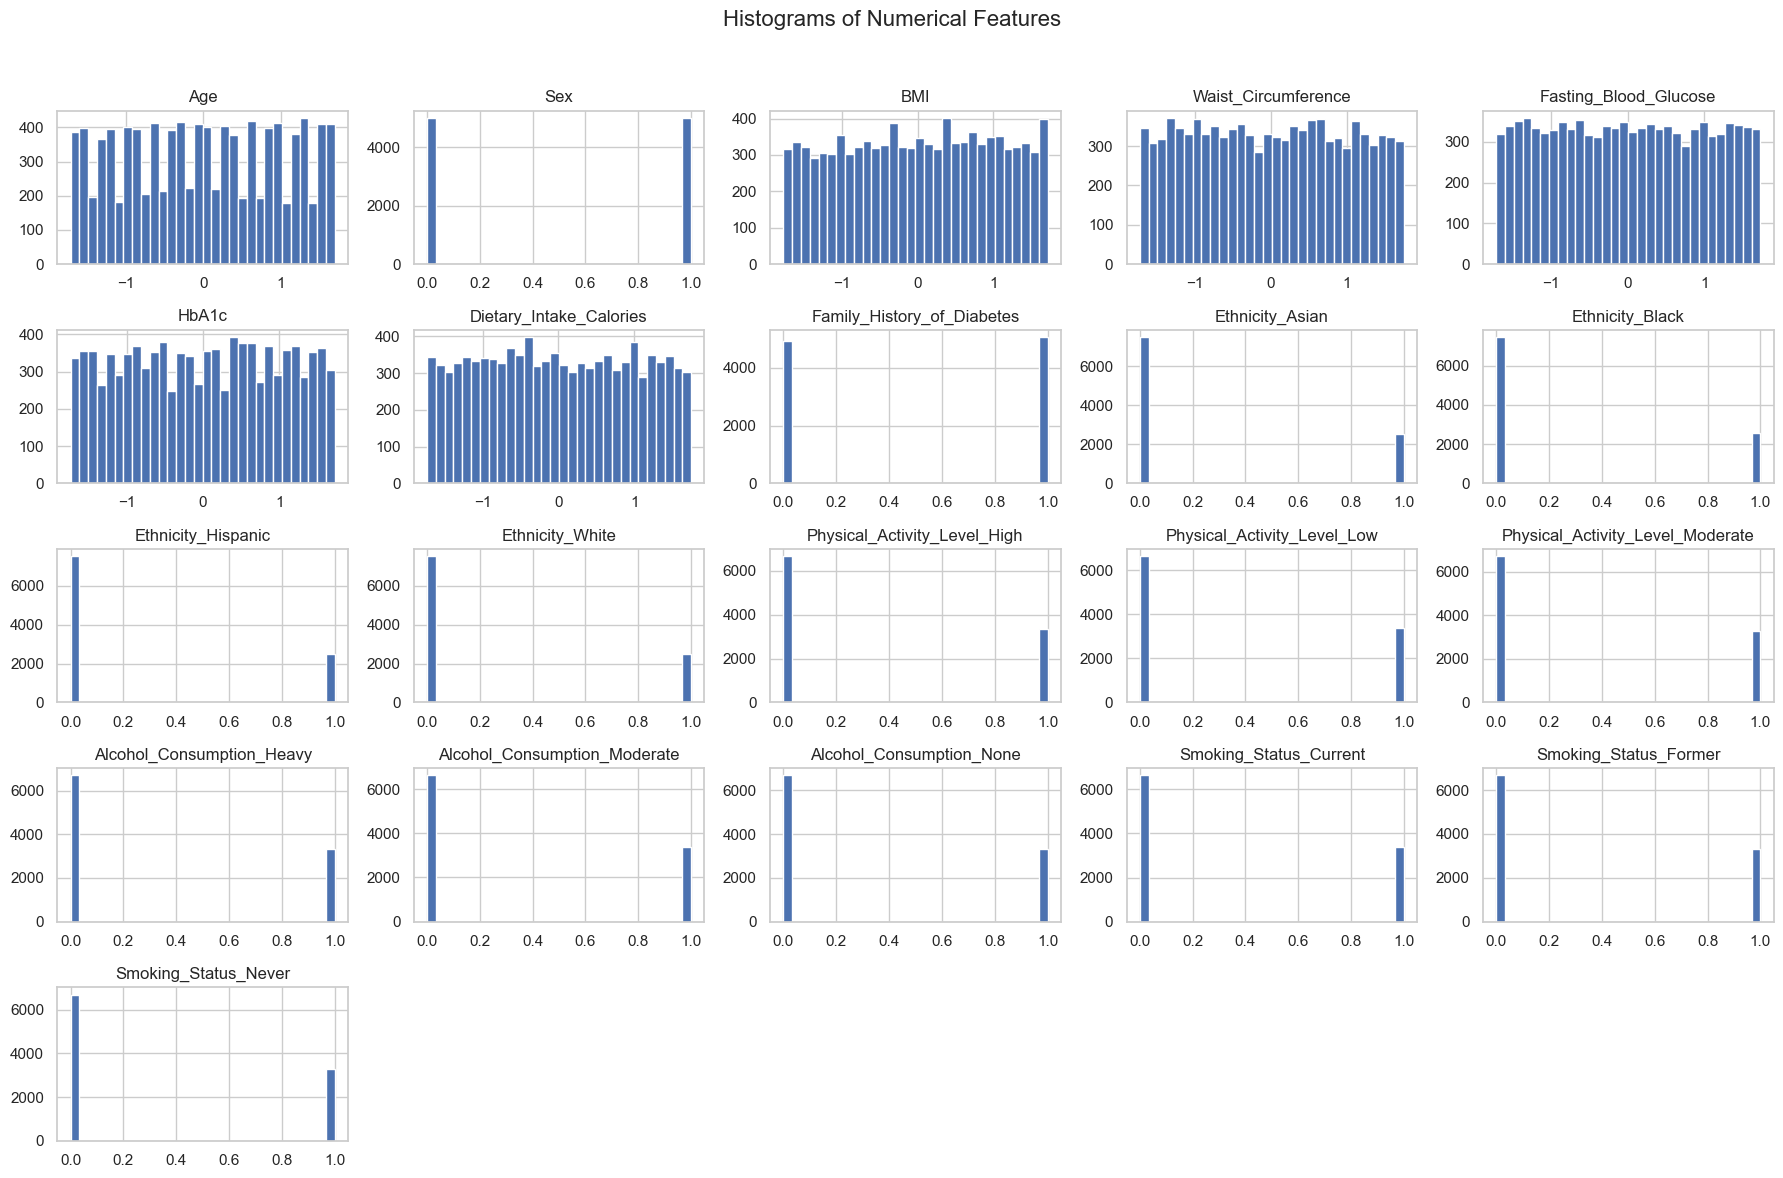

In [32]:

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Diabetes"]

df[numeric_cols].hist(bins=30, figsize=(18, 12))
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


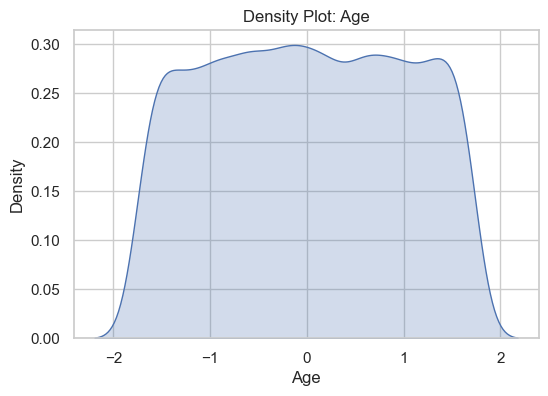

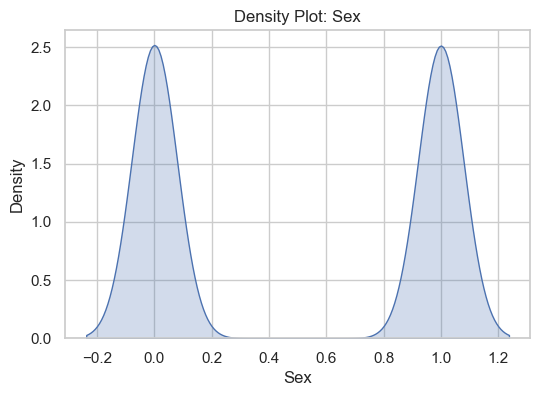

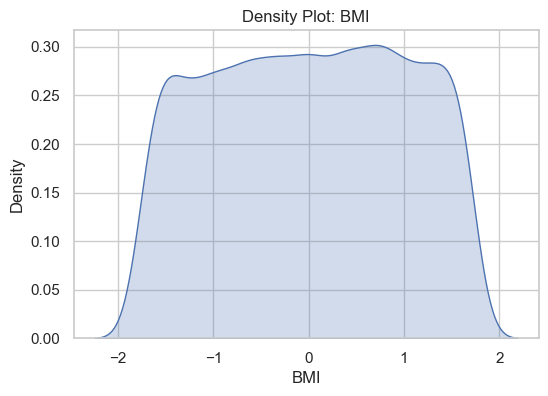

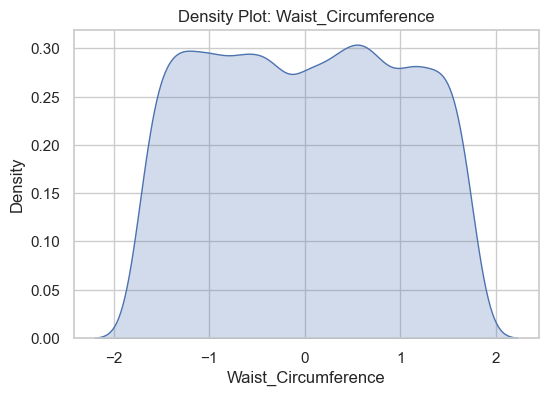

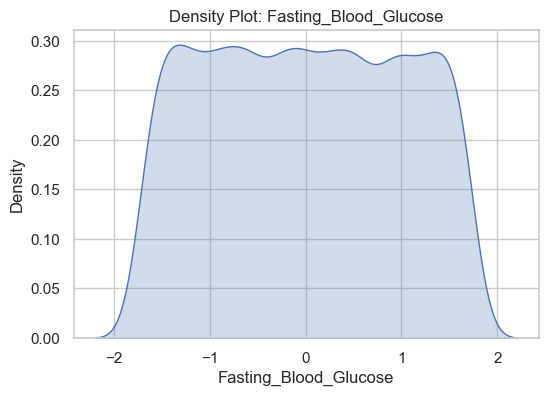

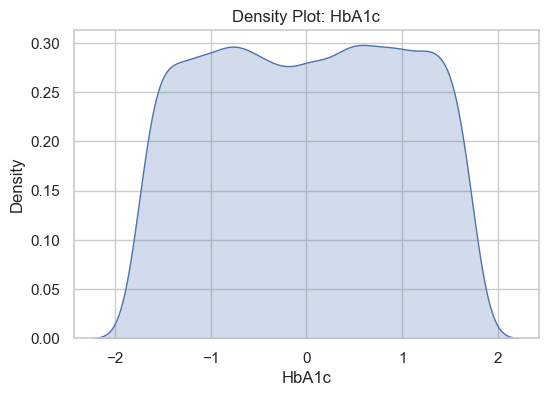

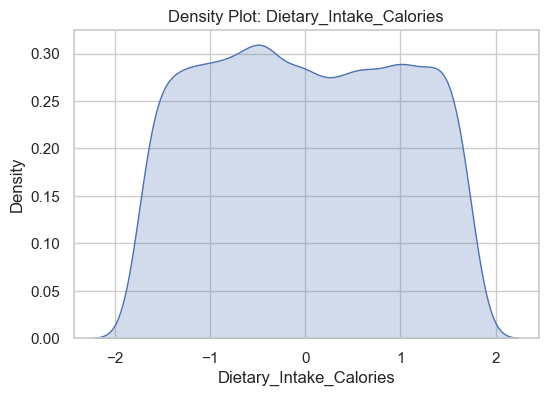

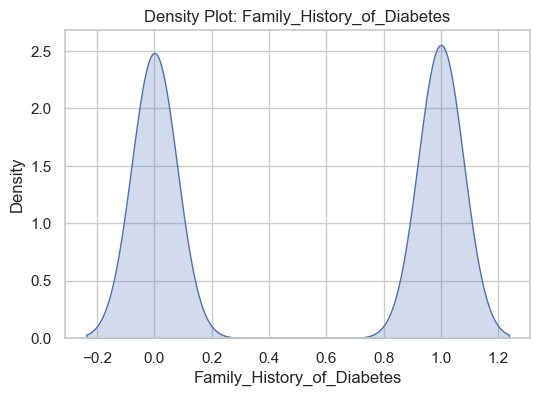

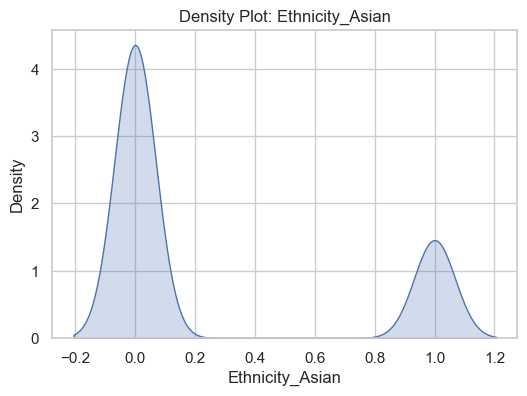

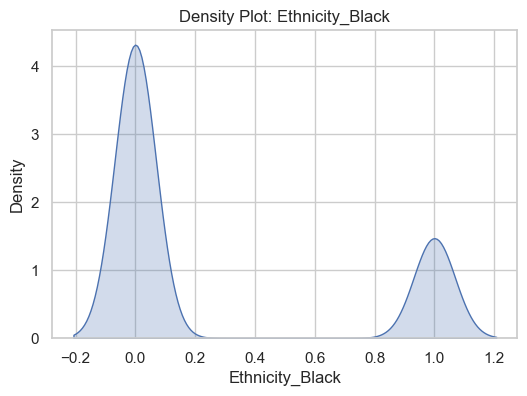

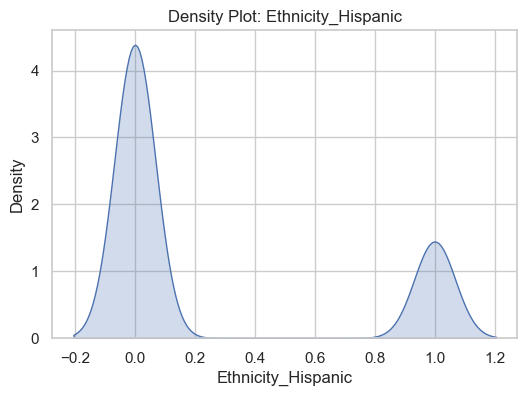

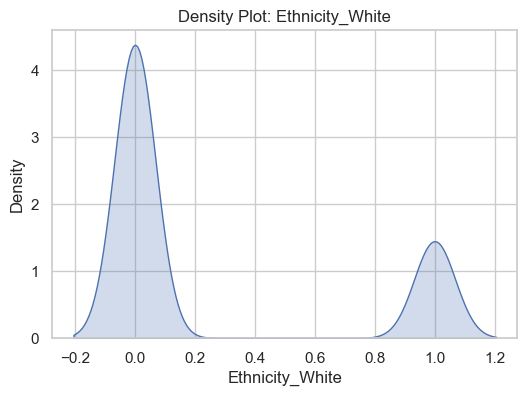

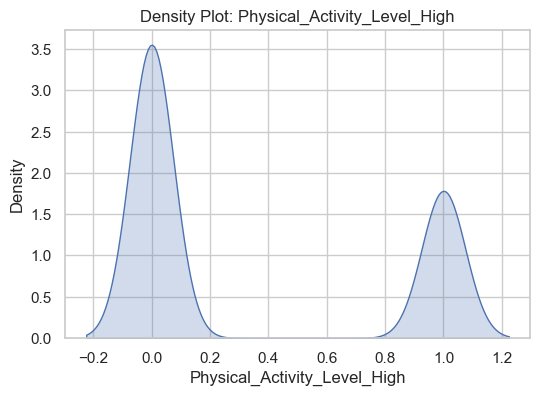

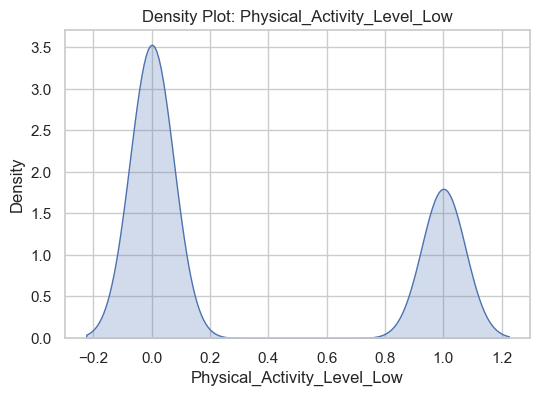

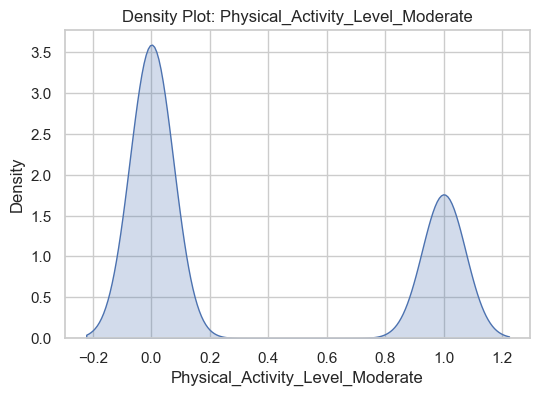

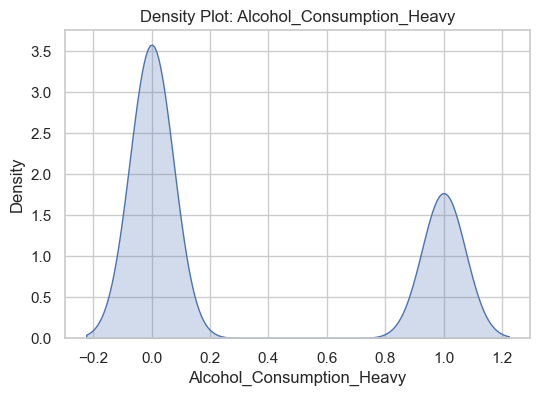

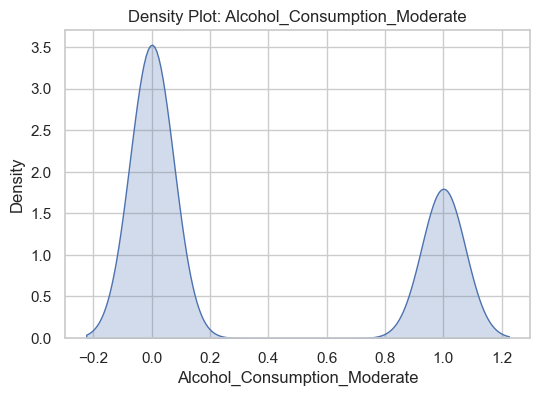

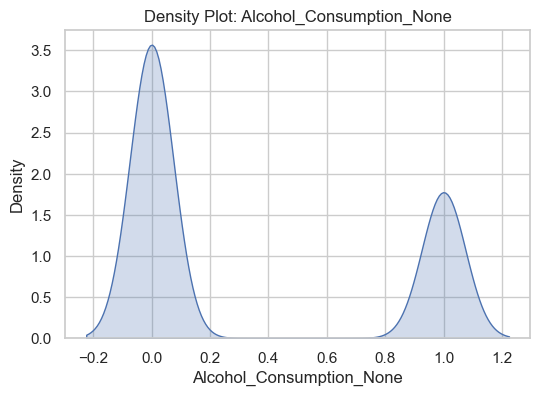

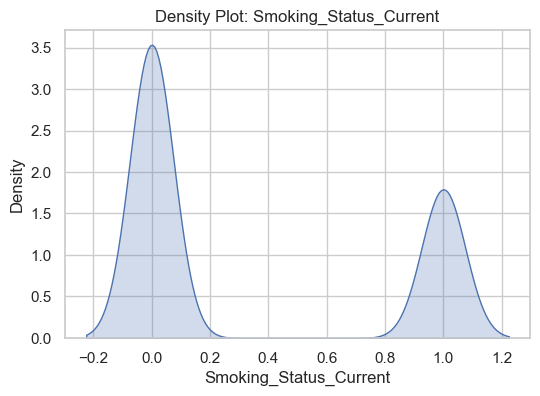

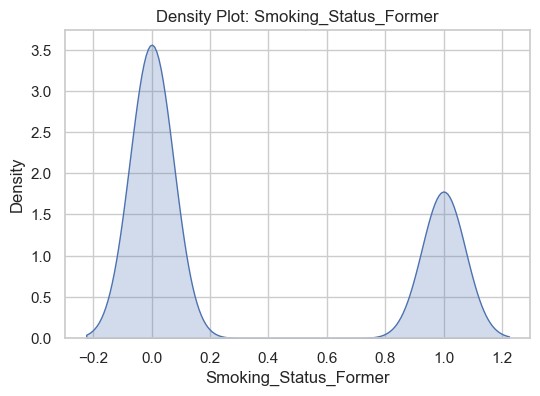

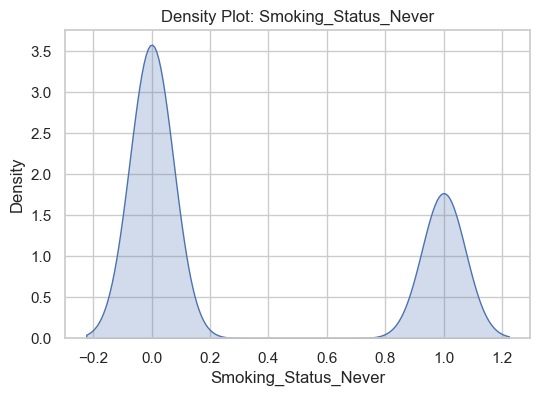

In [47]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Density Plot: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()


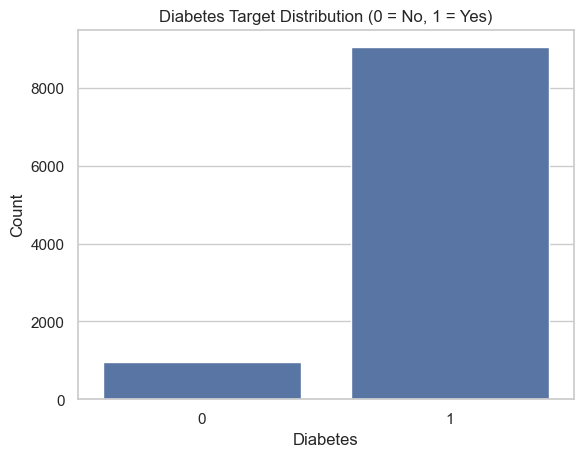

In [34]:
sns.countplot(x="Diabetes", data=df)
plt.title("Diabetes Target Distribution (0 = No, 1 = Yes)")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()


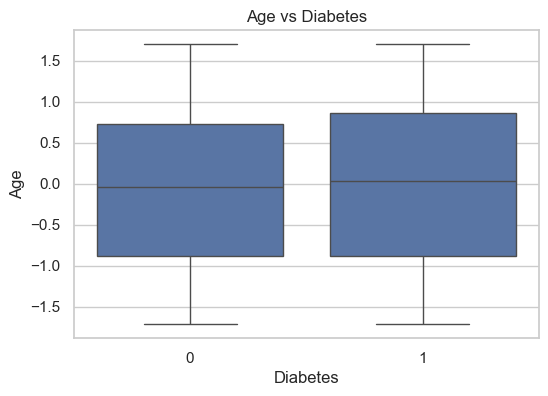

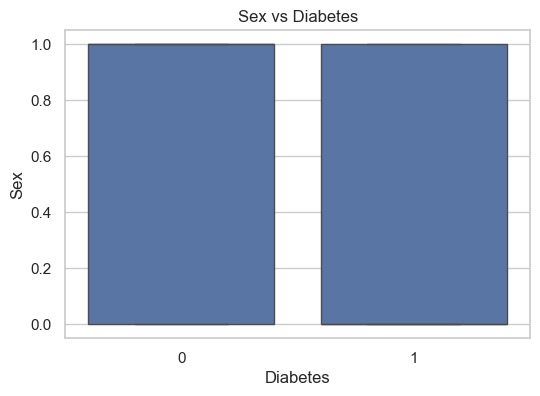

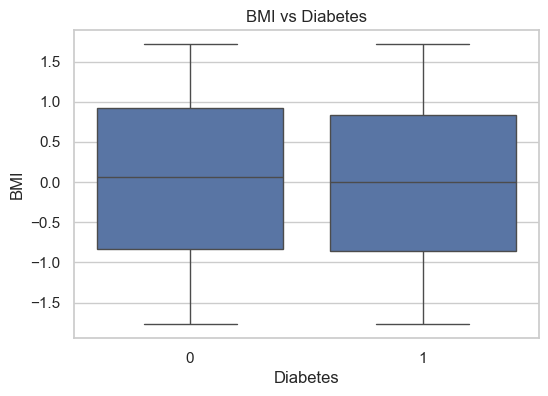

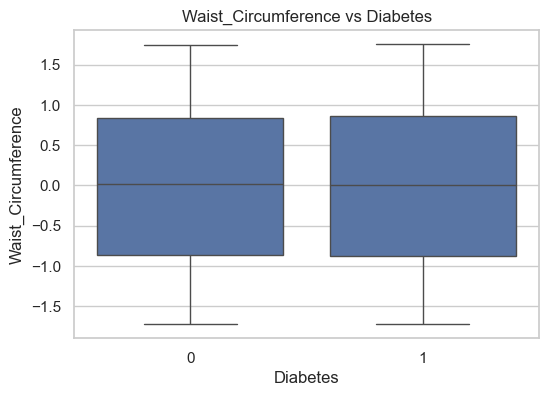

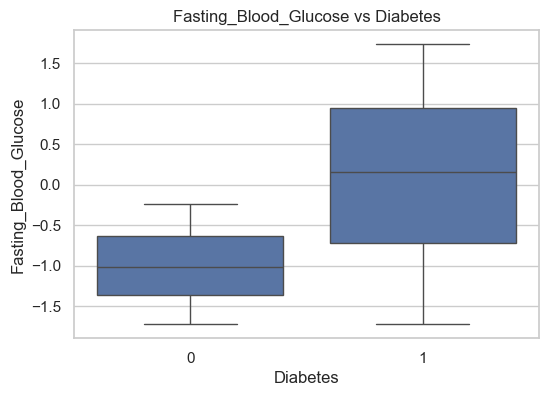

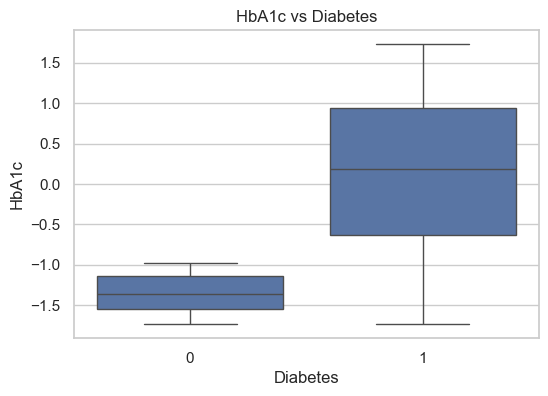

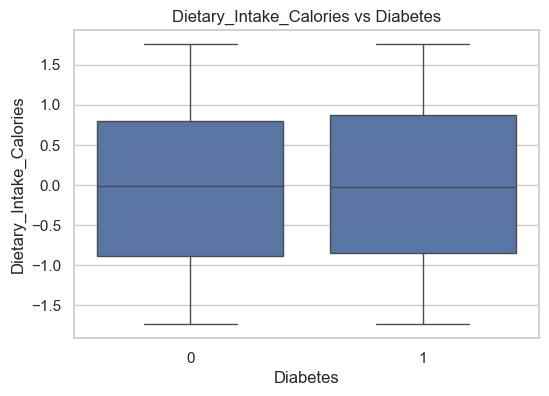

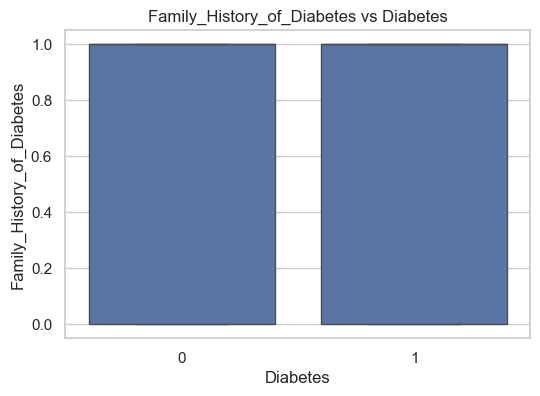

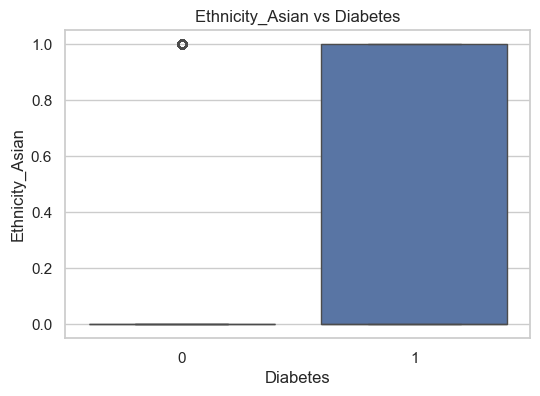

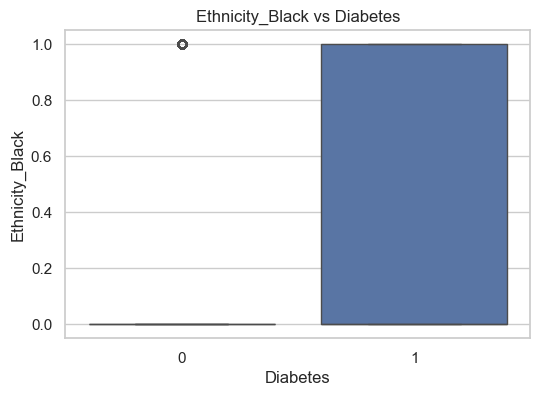

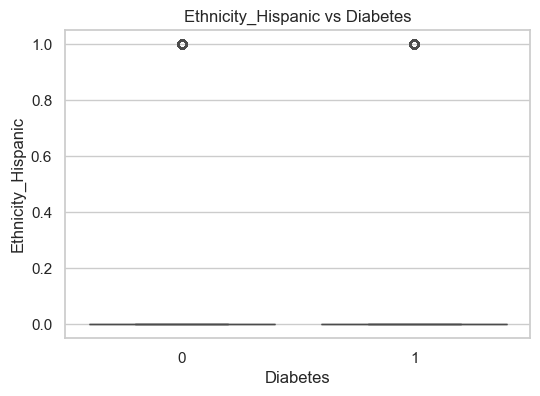

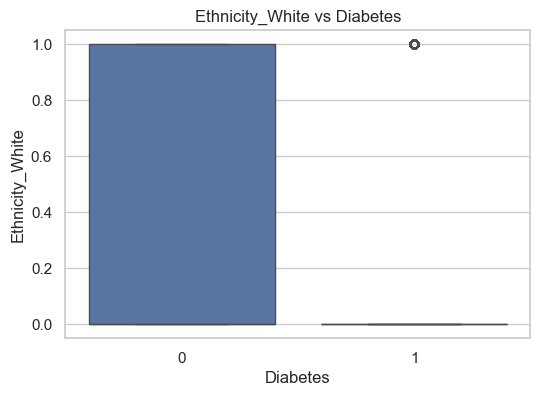

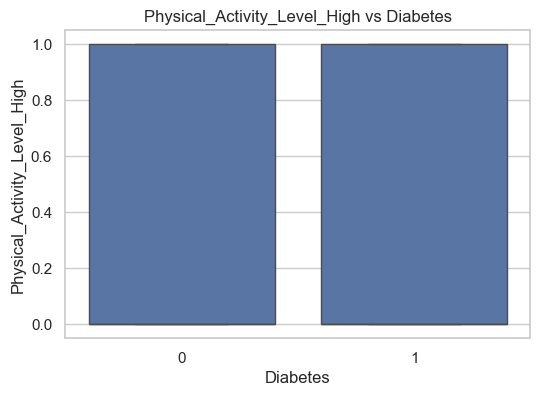

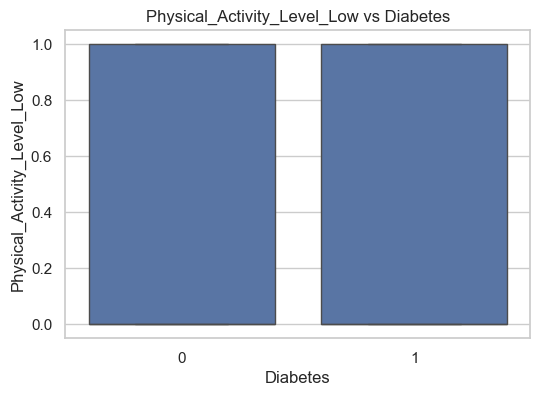

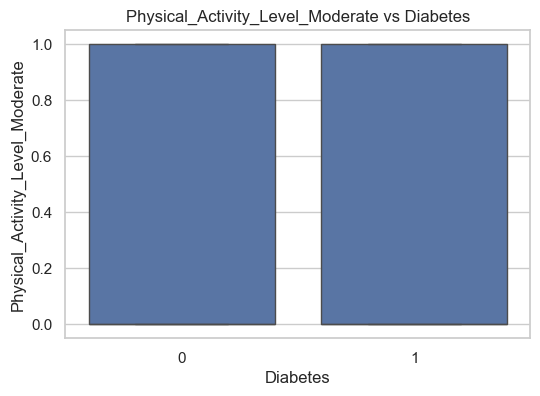

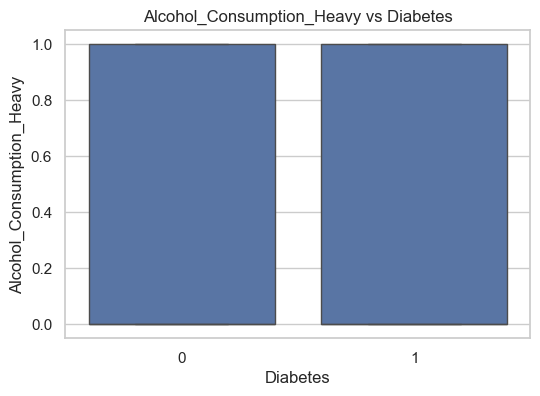

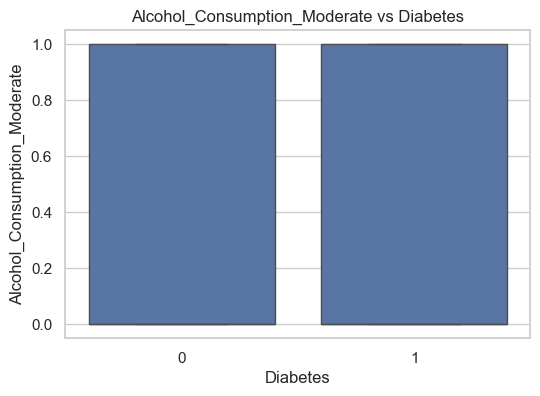

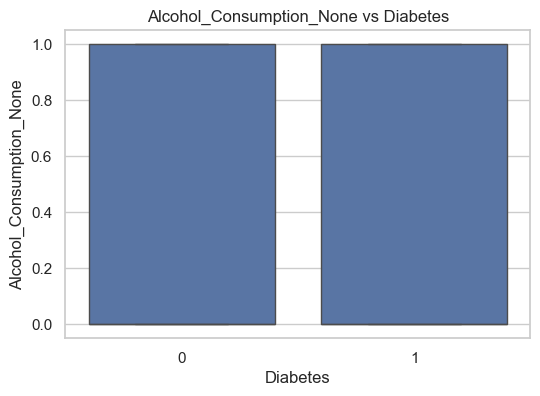

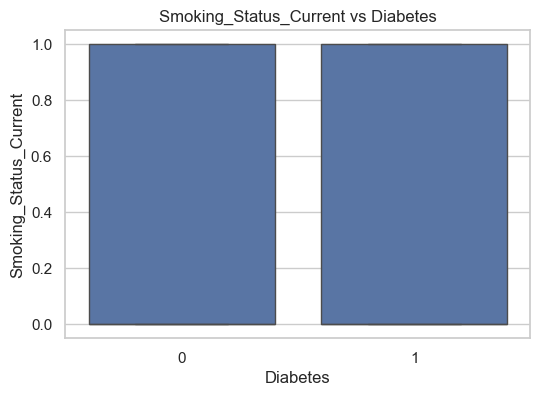

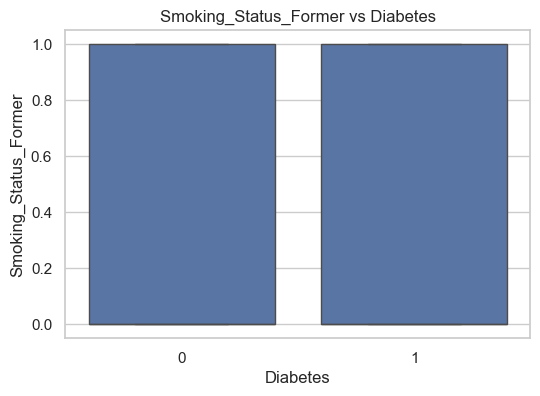

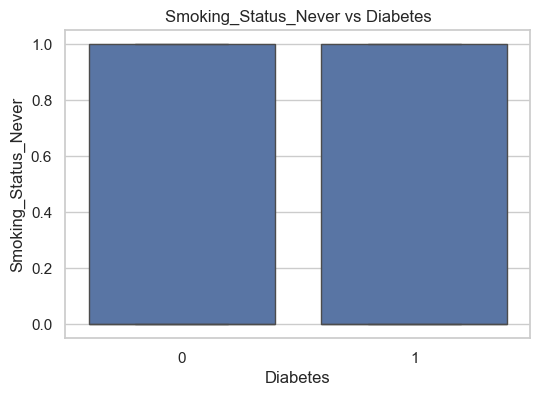

In [43]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Diabetes", y=col, data=df)
    plt.title(f"{col} vs Diabetes")
    plt.show()


In [19]:
group_means = df.groupby("Diabetes")[numeric_cols].mean().T
group_means.columns = ["Mean (Diabetes=0)", "Mean (Diabetes=1)"]
group_means["Difference (1 - 0)"] = group_means["Mean (Diabetes=1)"] - group_means["Mean (Diabetes=0)"]

group_means.sort_values("Difference (1 - 0)", ascending=False).head(15)


,Mean (Diabetes=0),Mean (Diabetes=1),Difference (1 - 0)
HbA1c,-1.344561,0.141634,1.486196
Fasting_Blood_Glucose,-0.991274,0.104420,1.095693
Age,-0.049840,0.005250,0.055090
Dietary_Intake_Calories,-0.021745,0.002291,0.024036
Physical_Activity_Level_High,0.315845,0.336023,0.020178
Alcohol_Consumption_Moderate,0.321091,0.339007,0.017916
Smoking_Status_Never,0.317943,0.331933,0.013990
Ethnicity_Asian,0.243442,0.251022,0.007581
Ethnicity_Black,0.248688,0.254449,0.005761
Physical_Activity_Level_Low,0.334732,0.337460,0.002728


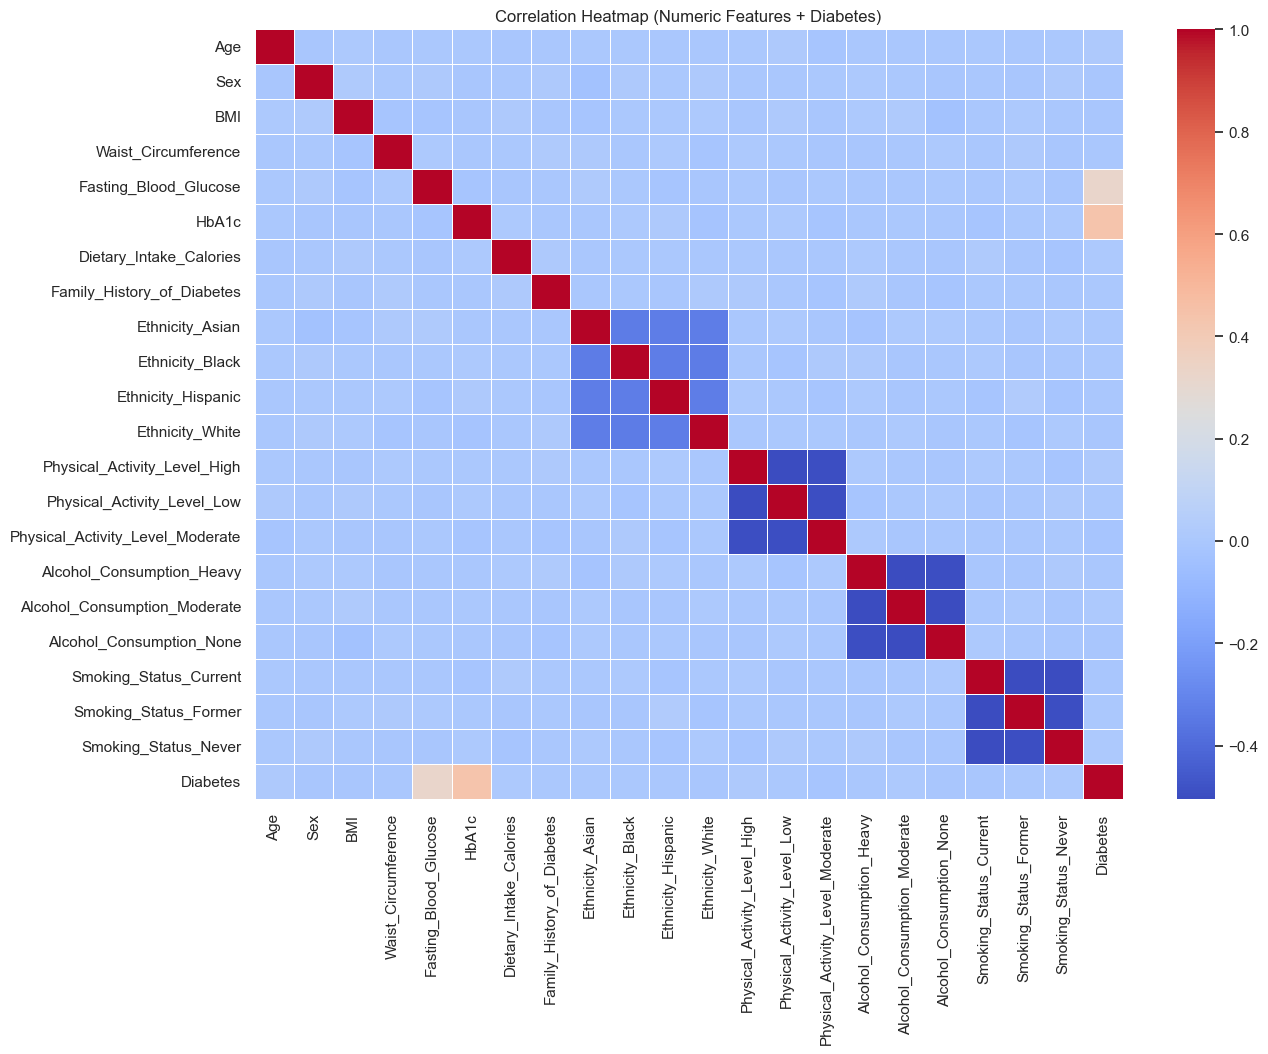

In [22]:
corr = df[numeric_cols + ["Diabetes"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features + Diabetes)")
plt.show()


In [23]:
target_corr = corr["Diabetes"].sort_values(ascending=False)
target_corr


Diabetes                            1.000000
HbA1c                               0.436390
Fasting_Blood_Glucose               0.321727
Age                                 0.016176
Physical_Activity_Level_High        0.012561
Alcohol_Consumption_Moderate        0.011127
Smoking_Status_Never                0.008732
Dietary_Intake_Calories             0.007058
Ethnicity_Asian                     0.005138
Ethnicity_Black                     0.003886
Physical_Activity_Level_Low         0.001694
Smoking_Status_Former               0.000975
Family_History_of_Diabetes          0.000798
Ethnicity_Hispanic                 -0.000029
Waist_Circumference                -0.002685
Alcohol_Consumption_Heavy          -0.003506
Alcohol_Consumption_None           -0.007669
BMI                                -0.008389
Sex                                -0.008839
Ethnicity_White                    -0.009039
Smoking_Status_Current             -0.009667
Physical_Activity_Level_Moderate   -0.014318
Name: Diab

Selected features for pairplot: ['HbA1c', 'Fasting_Blood_Glucose', 'Age', 'Physical_Activity_Level_Moderate', 'Physical_Activity_Level_High', 'Diabetes']


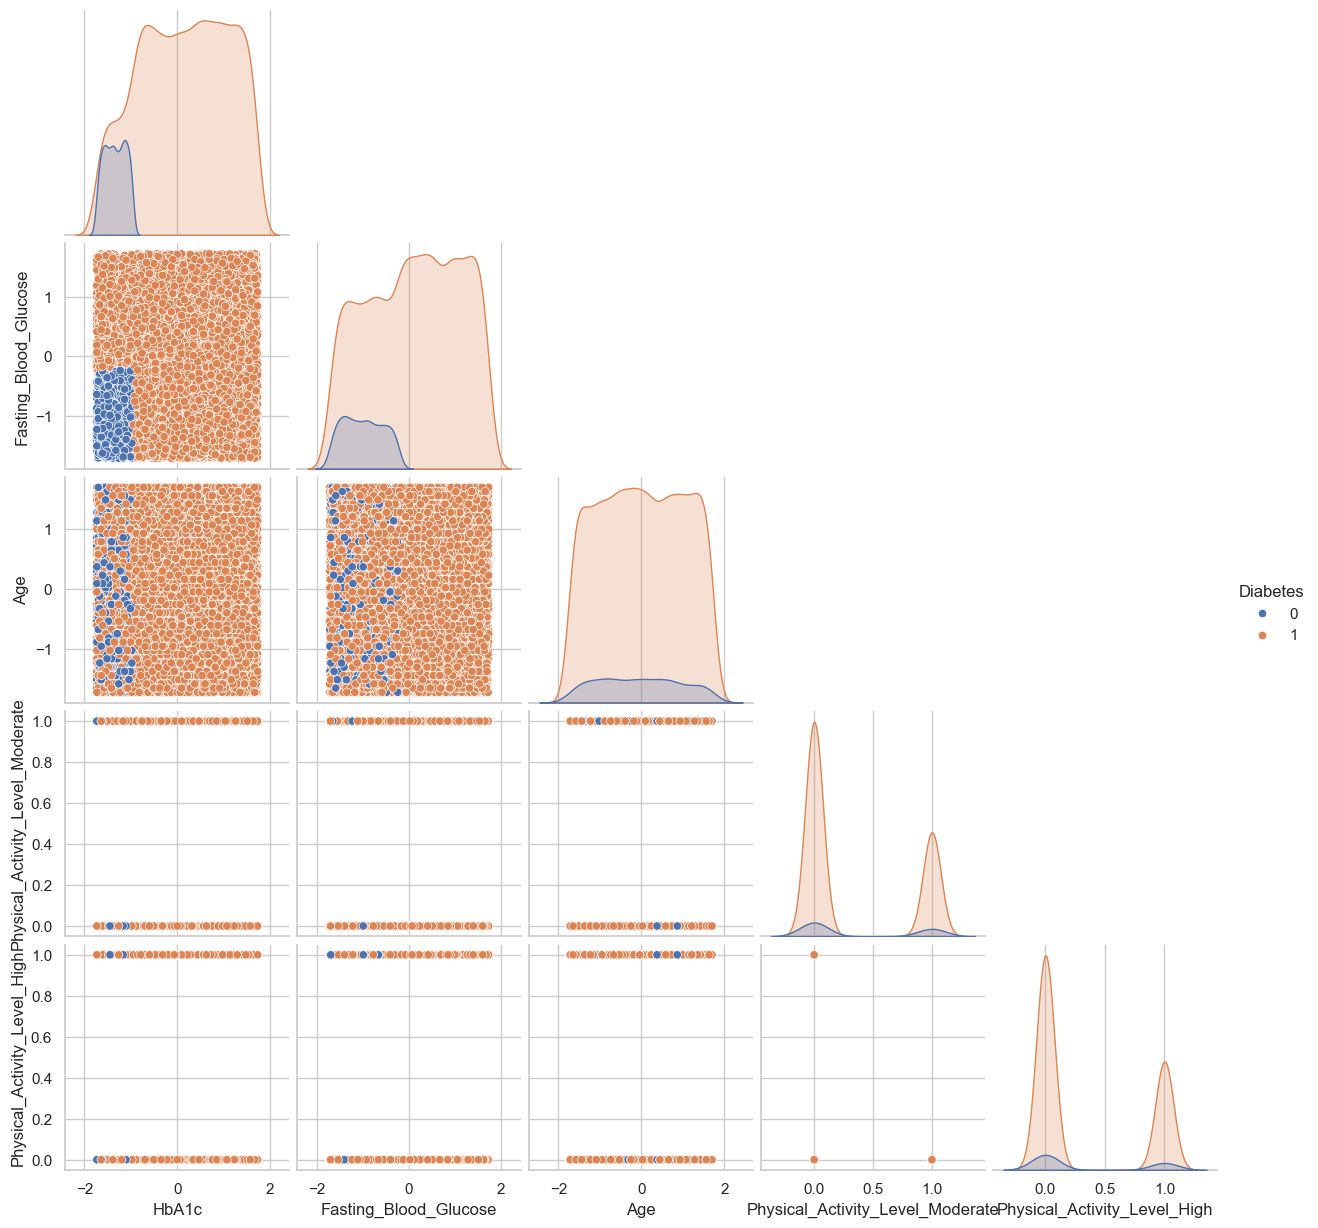

In [24]:
# Pick top 5 correlated features with Diabetes (excluding Diabetes itself)
top5 = target_corr.drop("Diabetes").abs().sort_values(ascending=False).head(5).index.tolist()

selected = top5 + ["Diabetes"]
print("Selected features for pairplot:", selected)

sns.pairplot(df[selected], hue="Diabetes", diag_kind="kde", corner=True)
plt.show()


In [25]:
binary_cols = [
    c for c in df1.columns
    if c != "Diabetes" and df1[c].nunique() == 2 and set(df1[c].unique()).issubset({0,1})
]

print("✅ Number of binary/one-hot columns:", len(binary_cols))
binary_cols[:]


✅ Number of binary/one-hot columns: 2


['Family_History_of_Diabetes', 'Previous_Gestational_Diabetes']

In [26]:
binary_summary = []

for c in binary_cols:
    # Diabetes rate when the category is present (value=1)
    subset = df1[df1[c] == 1]
    if len(subset) >= 20:  # avoid tiny groups
        rate = subset["Diabetes"].mean()
        binary_summary.append({"Feature": c, "Count": len(subset), "Diabetes_Rate": rate})

binary_summary_df = pd.DataFrame(binary_summary).sort_values("Diabetes_Rate", ascending=False)

binary_summary_df.head(20)


,Feature,Count,Diabetes_Rate
0,Family_History_of_Diabetes,5070,1.0
1,Previous_Gestational_Diabetes,5165,1.0


In [26]:
group_means.to_csv("../data/eda_group_means.csv")
target_corr.to_csv("../data/eda_target_correlation.csv")

print("✅ Saved:")
print("- ../data/eda_group_means.csv")
print("- ../data/eda_target_correlation.csv")


✅ Saved:
- ../data/eda_group_means.csv
- ../data/eda_target_correlation.csv
